In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from web_attack_detector_utils import *

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [4]:
# Load and prepare data
df = pd.read_csv('data/csic_database.csv')
df = df.rename(columns={'Unnamed: 0': 'Class'})

# Process data
X, label_encoders = preprocess_data(df)
y = df['Class']

In [5]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(['Normal', 'Anomalous'])
y_encoded = label_encoder.transform(y)

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Train traditional ML models
results_df, best_model = train_models(X_train_scaled, y_train, X_test_scaled, y_test)


Training Random Forest...
Random Forest Accuracy: 0.9228

Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.9164

Training Decision Tree...
Decision Tree Accuracy: 0.9182

Training Logistic Regression...
Logistic Regression Accuracy: 0.7775

Training Support Vector Machine...
Support Vector Machine Accuracy: 0.8120

Training Gradient Boosting...
Gradient Boosting Accuracy: 0.8749

Training XGBoost...
XGBoost Accuracy: 0.9198


In [7]:
def train_deep_learning_models(X_train, y_train, X_test, y_test, num_classes):
    """Train and evaluate deep learning models"""
    # MLP Model
    mlp_model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # CNN Model
    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    cnn_model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
        BatchNormalization(),
        Dropout(0.3),
        Conv1D(32, 3, activation='relu'),
        BatchNormalization(),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train models
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    y_train_cat = to_categorical(y_train, num_classes)
    y_test_cat = to_categorical(y_test, num_classes)
    
    print("\nTraining MLP...")
    mlp_history = mlp_model.fit(X_train, y_train_cat, 
                               validation_data=(X_test, y_test_cat),
                               epochs=25, batch_size=64, callbacks=[early_stop], verbose=1)
    
    print("\nTraining CNN...")
    cnn_history = cnn_model.fit(X_train_cnn, y_train_cat,
                               validation_data=(X_test_cnn, y_test_cat),
                               epochs=25, batch_size=64, callbacks=[early_stop], verbose=1)
    
    return mlp_model, cnn_model, mlp_history, cnn_history

def evaluate_deep_learning(model, X_test, y_test, name="Model"):
    """Evaluate deep learning models"""
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    print(f"\n{name} Evaluation:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision'],
        'Recall': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall'],
        'F1-Score': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    }

In [8]:
# Train deep learning models
num_classes = len(np.unique(y_encoded))
mlp_model, cnn_model, mlp_history, cnn_history = train_deep_learning_models(
    X_train_scaled, y_train, X_test_scaled, y_test, num_classes
)

# Evaluate deep learning models
mlp_results = evaluate_deep_learning(mlp_model, X_test_scaled, y_test, "MLP")
cnn_results = evaluate_deep_learning(cnn_model, 
                                    X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1), 
                                    y_test, "CNN")


Training MLP...
Epoch 1/25


c:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7625 - loss: 0.4687 - val_accuracy: 0.8042 - val_loss: 0.3628
Epoch 2/25
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8025 - loss: 0.3700 - val_accuracy: 0.8104 - val_loss: 0.3563
Epoch 3/25
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8134 - loss: 0.3562 - val_accuracy: 0.8057 - val_loss: 0.3498
Epoch 4/25
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8159 - loss: 0.3507 - val_accuracy: 0.8080 - val_loss: 0.3469
Epoch 5/25
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8191 - loss: 0.3452 - val_accuracy: 0.8144 - val_loss: 0.3460
Epoch 6/25
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8184 - loss: 0.3407 - val_accuracy: 0.8210 - val_loss: 0.3404
Epoch 7/25
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8184 - loss: 0.3406 - val_accuracy: 0.8266 - val_loss: 0.3405
Epoch 8/25
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8194 - loss: 0.3387 - val_accuracy: 0.8150 - val_

In [9]:
print(f"MLP (Deep Learning) Accuracy: {mlp_results['Accuracy']:.4f}")
print(f"\nCNN (Deep Learning) Accuracy: {cnn_results['Accuracy']:.4f}")

MLP (Deep Learning) Accuracy: 0.8353

CNN (Deep Learning) Accuracy: 0.8556


In [10]:
dl_results = pd.DataFrame([
    {'Model': 'MLP (Deep Learning)', **mlp_results},
    {'Model': 'CNN (Deep Learning)', **cnn_results}
])
results_df = pd.concat([results_df, dl_results]).sort_values('Accuracy', ascending=False)

In [12]:
# Save the best model pipeline
save_model_pipeline(best_model, scaler, label_encoder, label_encoders, X.columns.tolist(), 'web_attack_model.pkl')

Model pipeline saved to web_attack_model.pkl


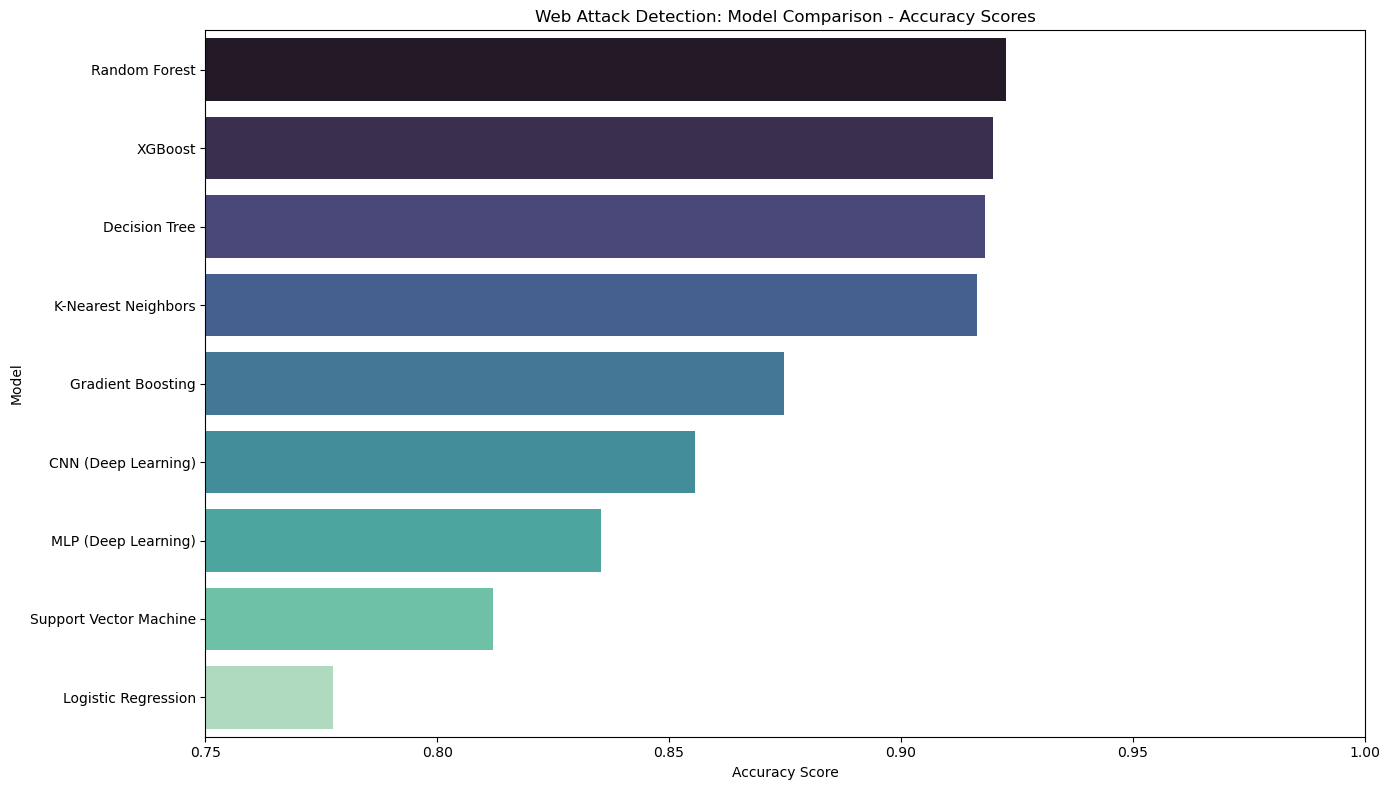

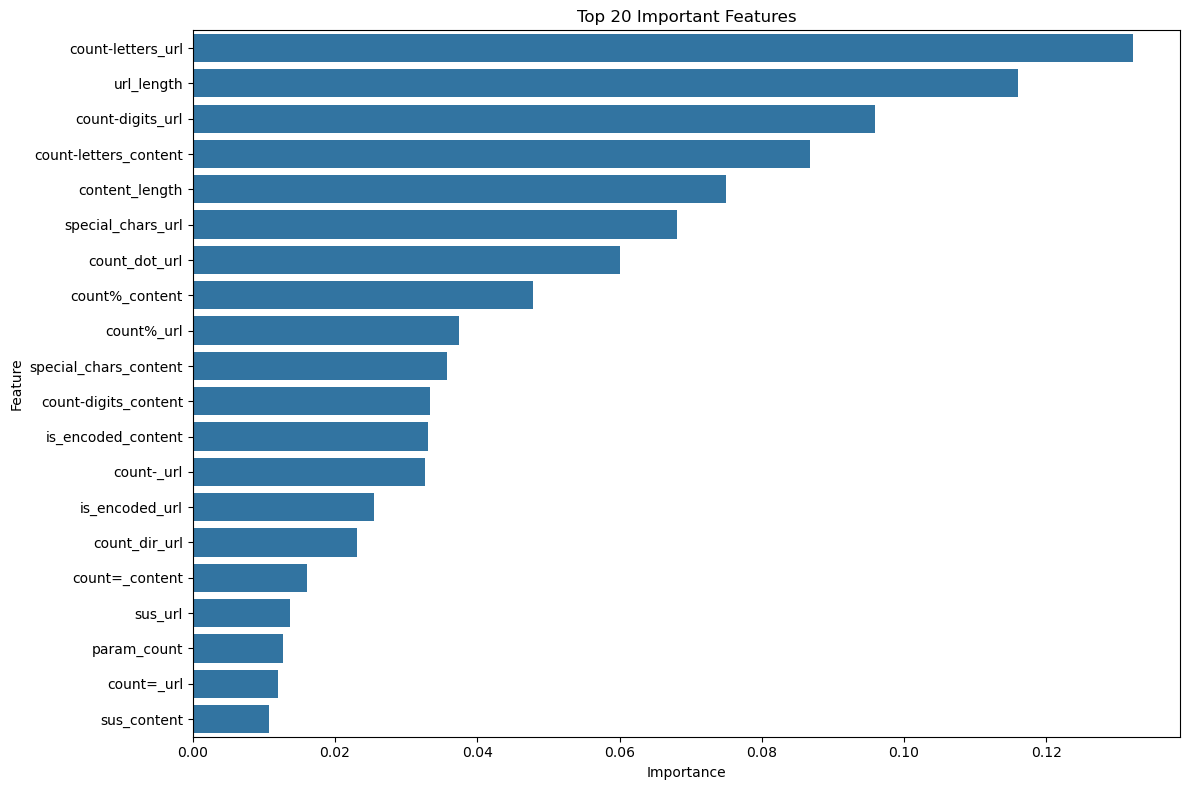

In [13]:
# Visualize results
plot_model_comparison(results_df)
plot_feature_importance(best_model, X.columns.tolist())

In [14]:
# Print final results
print("\n🔍 Final Model Performance Comparison:")
print(results_df.to_markdown(tablefmt="grid", index=False))


🔍 Final Model Performance Comparison:
+------------------------+------------+-------------+----------+------------+
| Model                  |   Accuracy |   Precision |   Recall |   F1-Score |
+========================+============+=============+==========+============+
| Random Forest          |   0.922762 |    0.922752 | 0.922762 |   0.922757 |
+------------------------+------------+-------------+----------+------------+
| XGBoost                |   0.919814 |    0.919694 | 0.919814 |   0.919698 |
+------------------------+------------+-------------+----------+------------+
| Decision Tree          |   0.918177 |    0.918052 | 0.918177 |   0.918058 |
+------------------------+------------+-------------+----------+------------+
| K-Nearest Neighbors    |   0.916376 |    0.916306 | 0.916376 |   0.916334 |
+------------------------+------------+-------------+----------+------------+
| Gradient Boosting      |   0.874891 |    0.877722 | 0.874891 |   0.875459 |
+------------------------

#### PREDICTION PART

In [ ]:
pipeline = load_model_pipeline('web_attack_model.pkl')

result = predict_web_attack(
    "http://localhost:8080/tienda1/index.jsp HTTP/1.1",
    pipeline=pipeline
)
print(result,'\n')

result = predict_web_attack(
    "https://newdomain.com/search?q=<script>alert(1)</script>",
    pipeline=pipeline
)
print(result)   

{'url': 'http://localhost:8080/tienda1/index.jsp HTTP/1.1', 'prediction': 'Normal', 'probability_normal': 1.0, 'probability_anomalous': 0.0, 'is_anomalous': False} 

{'url': 'https://newdomain.com/search?q=<script>alert(1)</script>', 'prediction': 'Anomalous', 'probability_normal': 0.11, 'probability_anomalous': 0.89, 'is_anomalous': True}


In [16]:
print(pipeline['label_encoder'].classes_)

['Normal' 'Anomalous']
